<a href="https://colab.research.google.com/github/Kopuraj/Student-Depression-ML/blob/main/notebooks/student_depression_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install any missing libraries
!pip install scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# Load the dataset from Drive
import pandas as pd

file_path = '/content/drive/MyDrive/EE7209_Project/Student Mental health.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (101, 11)


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [ ]:
# 1. Check shape
print("Shape:", df.shape)

# 2. Check column names (important! - column names may have extra spaces)
print("\nColumns:")
print(df.columns.tolist())

# 3. Check first few rows
df.head()

Shape: (101, 11)

Columns:
['Timestamp', 'Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [ ]:
# 4. Check data types
print(df.dtypes)

Timestamp                                        object
Choose your gender                               object
Age                                             float64
What is your course?                             object
Your current year of Study                       object
What is your CGPA?                               object
Marital status                                   object
Do you have Depression?                          object
Do you have Anxiety?                             object
Do you have Panic attack?                        object
Did you seek any specialist for a treatment?     object
dtype: object


In [ ]:
# 5. Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Timestamp                                       0
Choose your gender                              0
Age                                             1
What is your course?                            0
Your current year of Study                      0
What is your CGPA?                              0
Marital status                                  0
Do you have Depression?                         0
Do you have Anxiety?                            0
Do you have Panic attack?                       0
Did you seek any specialist for a treatment?    0
dtype: int64


In [ ]:
# 6. Check target variable
print("Target Variable Distribution:")
print(df['Do you have Depression?'].value_counts())

Target Variable Distribution:
Do you have Depression?
No     66
Yes    35
Name: count, dtype: int64


### Exploratory Data Analysis (EDA)

In [ ]:
# Basic info
print("=== Dataset Info ===")
print(df.info())
print("\n=== Basic Statistics ===")
print(df.describe())
print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                   

In [ ]:
# Column names
print("Columns:", df.columns.tolist())

Columns: ['Timestamp', 'Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']



=== Target Variable - Depression ===
Do you have Depression?
No     66
Yes    35
Name: count, dtype: int64


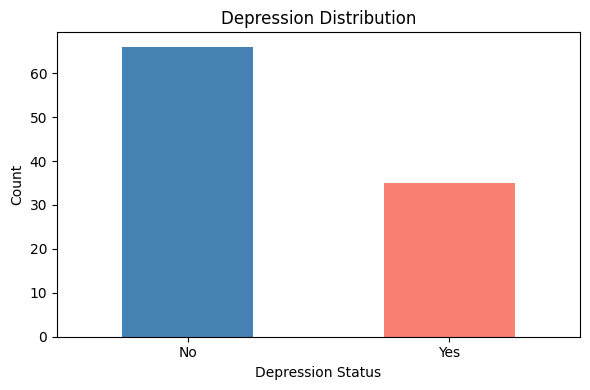

In [ ]:
# Check target variable distribution
print("\n=== Target Variable - Depression ===")
print(df['Do you have Depression?'].value_counts())

plt.figure(figsize=(6,4))
df['Do you have Depression?'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Depression Distribution')
plt.xlabel('Depression Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('depression_distribution.png')
plt.show()

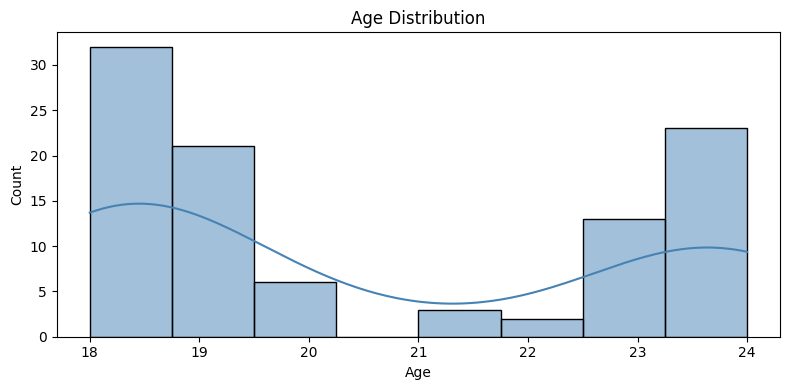

In [ ]:
# Distribution of Age
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], kde=True, color='steelblue')
plt.title('Age Distribution')
plt.tight_layout()
plt.show()

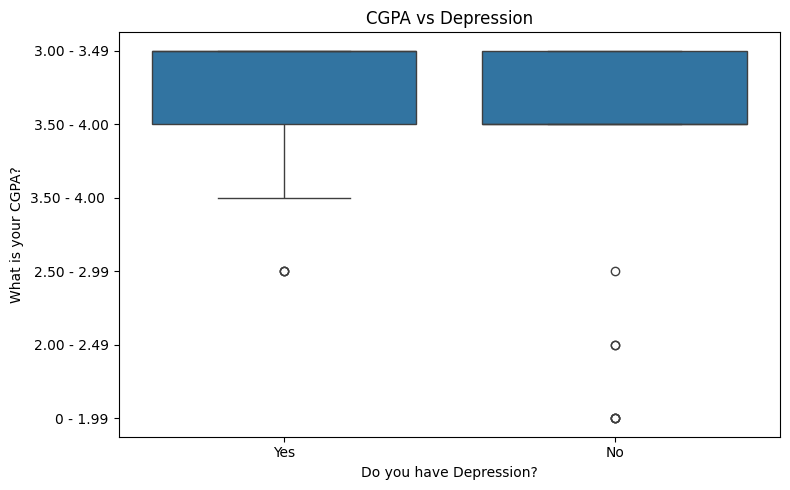

In [ ]:
# Depression vs CGPA
plt.figure(figsize=(8,5))
sns.boxplot(x='Do you have Depression?', y='What is your CGPA?', data=df)
plt.title('CGPA vs Depression')
plt.tight_layout()
plt.show()

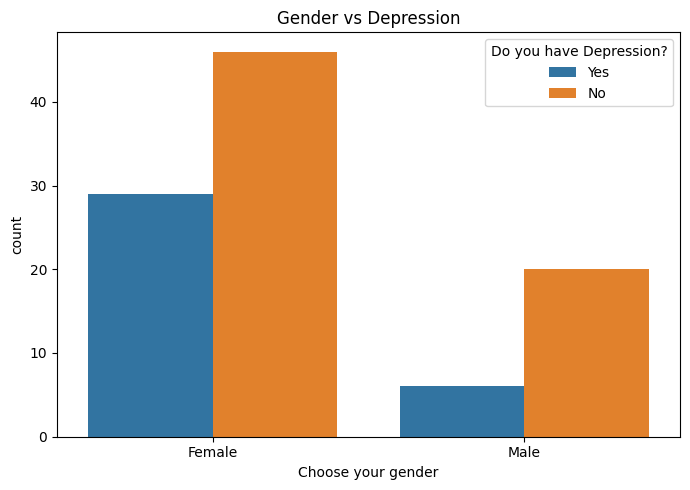

In [ ]:
# Depression vs Gender
plt.figure(figsize=(7,5))
sns.countplot(x='Choose your gender', hue='Do you have Depression?', data=df)
plt.title('Gender vs Depression')
plt.tight_layout()
plt.show()

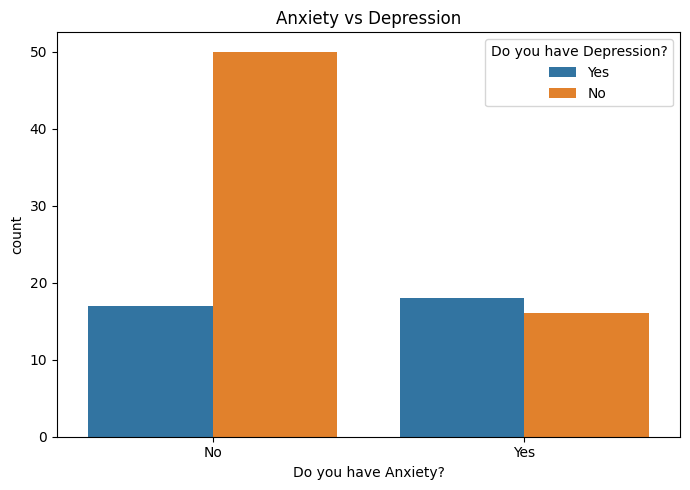

In [ ]:
# Depression vs Anxiety
plt.figure(figsize=(7,5))
sns.countplot(x='Do you have Anxiety?', hue='Do you have Depression?', data=df)
plt.title('Anxiety vs Depression')
plt.tight_layout()
plt.show()

### Data Preprocessing

In [ ]:
# Make a copy to avoid modifying original
data = df.copy()

# Check column names first (they may have spaces)
print(data.columns.tolist())

['Timestamp', 'Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']


In [ ]:
# Rename columns to simpler names for easier handling
data.columns = data.columns.str.strip()  # remove leading/trailing spaces

# Rename to cleaner names
data.rename(columns={
    'Choose your gender': 'Gender',
    'What is your CGPA?': 'CGPA',
    'Do you have Depression?': 'Depression',
    'Do you have Anxiety?': 'Anxiety',
    'Do you have Panic attack?': 'Panic_Attack',
    'Did you seek any specialist for a treatment?': 'Sought_Treatment',
    'What is your course?': 'Course',
    'Your current year of Study': 'Year',
    'Marital status': 'Marital_Status'
}, inplace=True)

print("Columns after rename:", data.columns.tolist())

Columns after rename: ['Timestamp', 'Gender', 'Age', 'Course', 'Year', 'CGPA', 'Marital_Status', 'Depression', 'Anxiety', 'Panic_Attack', 'Sought_Treatment']


In [ ]:
# Handle missing values
print("Missing values before handling:")
print(data.isnull().sum())

# Drop rows with missing values (dataset is small but clean)
data.dropna(inplace=True)
print(f"\nShape after dropping nulls: {data.shape}")

Missing values before handling:
Timestamp           0
Gender              0
Age                 1
Course              0
Year                0
CGPA                0
Marital_Status      0
Depression          0
Anxiety             0
Panic_Attack        0
Sought_Treatment    0
dtype: int64

Shape after dropping nulls: (100, 11)


In [ ]:
# Encode categorical variables using LabelEncoder
le = LabelEncoder()

categorical_cols = ['Gender', 'CGPA', 'Depression', 'Anxiety',
                    'Panic_Attack', 'Sought_Treatment', 'Course',
                    'Year', 'Marital_Status']

for col in categorical_cols:
    if col in data.columns:
        data[col] = le.fit_transform(data[col].astype(str))
        print(f"Encoded: {col}")

print("\nData after encoding:")
data.head()

Encoded: Gender
Encoded: CGPA
Encoded: Depression
Encoded: Anxiety
Encoded: Panic_Attack
Encoded: Sought_Treatment
Encoded: Course
Encoded: Year
Encoded: Marital_Status

Data after encoding:


,Timestamp,Gender,Age,Course,Year,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Sought_Treatment
0,8/7/2020 12:02,0,18.0,17,3,3,0,1,0,1,0
1,8/7/2020 12:04,1,21.0,25,4,3,0,0,1,0,0
2,8/7/2020 12:05,1,19.0,4,0,3,0,1,1,1,0
3,8/7/2020 12:06,0,22.0,33,5,3,1,1,0,0,0
4,8/7/2020 12:13,1,23.0,37,6,3,0,0,0,0,0


In [ ]:
# Check encoded values
print(data.dtypes)
print("\nSample data:")
print(data.head())

Timestamp            object
Gender                int64
Age                 float64
Course                int64
Year                  int64
CGPA                  int64
Marital_Status        int64
Depression            int64
Anxiety               int64
Panic_Attack          int64
Sought_Treatment      int64
dtype: object

Sample data:
        Timestamp  Gender   Age  Course  Year  CGPA  Marital_Status  \
0  8/7/2020 12:02       0  18.0      17     3     3               0   
1  8/7/2020 12:04       1  21.0      25     4     3               0   
2  8/7/2020 12:05       1  19.0       4     0     3               0   
3  8/7/2020 12:06       0  22.0      33     5     3               1   
4  8/7/2020 12:13       1  23.0      37     6     3               0   

   Depression  Anxiety  Panic_Attack  Sought_Treatment  
0           1        0             1                 0  
1           0        1             0                 0  
2           1        1             1                 0  
3        

### Feature Selection & Splitting

In [ ]:
# Separate features and target
X = data.drop(columns=['Depression'])
y = data['Depression']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")
print(f"\nClass distribution:\n{y.value_counts()}")

Features shape: (100, 10)
Target shape: (100,)

Feature columns: ['Timestamp', 'Gender', 'Age', 'Course', 'Year', 'CGPA', 'Marital_Status', 'Anxiety', 'Panic_Attack', 'Sought_Treatment']

Class distribution:
Depression
0    65
1    35
Name: count, dtype: int64


In [ ]:
# Check for class imbalance
print("\nClass balance:")
print(y.value_counts(normalize=True) * 100)


Class balance:
Depression
0    65.0
1    35.0
Name: proportion, dtype: float64


In [ ]:
# Check what columns still exist in X
print(X.columns.tolist())
print(X.dtypes)

['Timestamp', 'Gender', 'Age', 'Course', 'Year', 'CGPA', 'Marital_Status', 'Anxiety', 'Panic_Attack', 'Sought_Treatment']
Timestamp            object
Gender                int64
Age                 float64
Course                int64
Year                  int64
CGPA                  int64
Marital_Status        int64
Anxiety               int64
Panic_Attack          int64
Sought_Treatment      int64
dtype: object


In [ ]:
# Drop the Timestamp column (not useful for prediction)
X = X.drop(columns=['Timestamp'], errors='ignore')

print("Columns after dropping Timestamp:")
print(X.columns.tolist())

Columns after dropping Timestamp:
['Gender', 'Age', 'Course', 'Year', 'CGPA', 'Marital_Status', 'Anxiety', 'Panic_Attack', 'Sought_Treatment']


In [ ]:
# Scale features (important for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features scaled successfully!")

Features scaled successfully!


In [ ]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (80, 9)
Testing set size: (20, 9)


## Random Forest Classifier